In [1]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns

import os

In [2]:
## Load in the processed POLECAT data 
df = pd.read_csv("data/POLECAT/processed_data/polecat.csv")

## Load in the country meta data
df_meta = pd.read_csv("data/POLECAT/processed_data/country_metadata.csv", index_col=0)
df_meta = df_meta.drop(columns='Country')

# Create a network object
df_network_raw = df[['Actor Country Id', 'Recipient Country Id', 
                 'Quad Code Id', 'Event Year Id', 'Event Month Id',
                 'Event Week Id', 'Event Day Id']]

# Basic plots

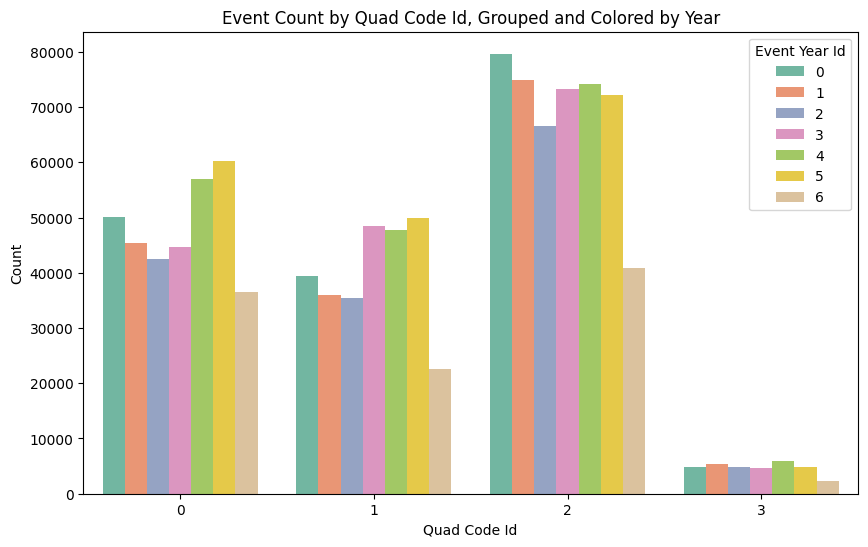

In [37]:
# Create the bar plot with bars side by side and coloured by Event Year Id
plt.figure(figsize=(10, 6))
sns.countplot(x='Quad Code Id', hue='Event Year Id', data=df, palette='Set2')

plt.title('Event Count by Quad Code Id, Grouped and Coloured by Year')
plt.xlabel('Quad Code Id')
plt.ylabel('Count')
plt.legend(title='Event Year Id')
plt.show();

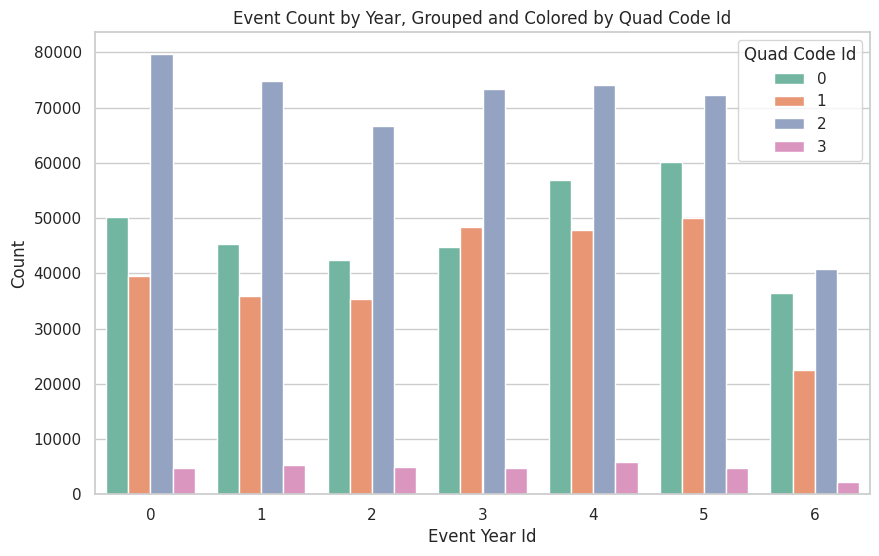

In [35]:
# Create the bar plot with Event Year Id on the x-axis and colored by Quad Code Id
plt.figure(figsize=(10, 6))
sns.countplot(x='Event Year Id', hue='Quad Code Id', data=df, palette='Set2')

plt.title('Event Count by Year, Grouped and Colored by Quad Code Id')
plt.xlabel('Event Year Id')
plt.ylabel('Count')
plt.legend(title='Quad Code Id')
plt.show();

# Functions to create dataframes 

In [3]:
"""
THIS WILL RESTRICT TO A PARTICULAR TIME WINDOW AND THEN AGREGGATE.

For example, df_network_y will take all data from that year, and construct a weighted
adjacency matrix.
"""
## Unrestricted ## 
df_network_full = df_network_raw.copy()
df_network_full = df_network_full.drop(columns=['Event Year Id', 'Event Month Id', 
                                                'Event Week Id', 'Event Day Id'])

# Weighted network
counts = df_network_full.groupby(df_network_full.columns.tolist()).size().reset_index(name='Weight')
df_network_full = pd.merge(df_network_full, counts, on=df_network_full.columns.to_list(), how='left') 
df_network_full = df_network_full.drop_duplicates()

def create_network_y(year: int, df_network: np.array=df_network_raw):
    """
    Create a network restricted to a given year.
    """
    df_network_y = df_network[df_network['Event Year Id'] == year].copy()
    
    # Reset to 0 index
    df_network_y = df_network_y.drop(columns=['Event Year Id', 'Event Month Id', 'Event Week Id', 
                                            'Event Day Id'])

    # Weighted network
    counts = df_network_y.groupby(df_network_y.columns.tolist()).size().reset_index(name='Weight')
    df_network_y = pd.merge(df_network_y, counts, on=df_network_y.columns.to_list(), how='left') 
    df_network_y = df_network_y.drop_duplicates()
    
    return df_network_y

def create_network_ym(year: int, month: int, df_network: np.array=df_network_raw):
    """
    Create a network restricted to a given year and month.
    """
    df_network_ym = df_network[df_network['Event Year Id'] == year].copy()
    
    # Reset to 0 index
    df_network_ym.loc[:, 'Event Month Id'] = df_network_ym['Event Month Id'] - df_network_ym['Event Month Id'].min()
    df_network_ym.loc[:, 'Event Day Id'] = df_network_ym['Event Day Id'] - df_network_ym['Event Day Id'].min()
    df_network_ym = df_network_ym[df_network_ym['Event Month Id'] == month]
    
    df_network_ym = df_network_ym.drop(columns=['Event Year Id', 'Event Month Id', 'Event Week Id'])

    # Weighted network 
    counts = df_network_ym.groupby(df_network_ym.columns.tolist()).size().reset_index(name='Weight')
    df_network_ym = pd.merge(df_network_ym, counts, on=df_network_ym.columns.to_list(), how='left')
    df_network_ym = df_network_ym.drop_duplicates()
    
    return df_network_ym

def create_network_ymd(year: int, month: int, day: int, 
                       df_network: np.array=df_network_raw):
    """
    Create a network restricted to a given year, month and day.
    """
    df_network_ymd = df_network[df_network['Event Year Id'] == year].copy()
    
    # Reset to 0 index
    df_network_ymd.loc[:, 'Event Month Id'] = df_network_ymd['Event Month Id'] - df_network_ymd['Event Month Id'].min()
    df_network_ymd = df_network_ymd[df_network_ymd['Event Month Id'] == month]
    
    df_network_ymd.loc[:, 'Event Day Id'] = df_network_ymd['Event Day Id'] - df_network_ymd['Event Day Id'].min()    
    df_network_ymd = df_network_ymd[df_network_ymd['Event Day Id'] == day]

    df_network_ymd = df_network_ymd.drop(columns=['Event Year Id', 'Event Month Id', 'Event Week Id', 
                                                'Event Day Id'])

    # Weighted network
    counts = df_network_ymd.groupby(df_network_ymd.columns.tolist()).size().reset_index(name='Weight')
    df_network_ymd = pd.merge(df_network_ymd, counts, on=df_network_ymd.columns.to_list(), how='left')
    df_network_ymd = df_network_ymd.drop_duplicates()
    
    return df_network_ymd

def create_network_w(week: int, df_network: np.array=df_network_raw):
    """
    Create a network restricted to a given week.
    """
    df_network_w = df_network[(df_network['Event Week Id'] == week)]
    df_network_w = df_network_w.drop(columns=['Event Year Id', 'Event Month Id', 'Event Week Id'])

    # Weighted network
    counts = df_network_w.groupby(df_network_w.columns.tolist()).size().reset_index(name='Weight')
    df_network_w = pd.merge(df_network_w, counts, on=df_network_w.columns.to_list(), how='left') 
    df_network_w = df_network_w.drop_duplicates()
    
    return df_network_w

"""
THIS WILL CONSTRUCT POINT PROCESSES ON DIFFERENT SCALES
"""

def create_network_pp(year: int=None, month: int=None, day: int=None,
                      y: bool=False, ym: bool=False, ymd: bool=False,
                      df_network: np.array=df_network_raw):
    """
    Create a network point process object.
    """
    if (y == True) & ((ym == True) | (ymd == True)):
        raise ValueError("Please select only one of y, ym or ymd.")
    if (ym == True) & ((y == True) | (ymd == True)):
        raise ValueError("Please select only one of y, ym or ymd.")
    if (ymd == True) & ((y == True) | (ym == True)):
        raise ValueError("Please select only one of y, ym or ymd.")
    
    if y == True:
        if year is None:
            raise ValueError("Supply a value for year.")
        df_network_pp = df_network.copy()
        df_network_pp = df_network_pp[df_network_pp['Event Year Id'] == year]
        
        # Shift values by smallest month, week and day
        df_network_pp['Event Month Id'] = df_network_pp['Event Month Id'] - df_network_pp['Event Month Id'].min()
        df_network_pp['Event Week Id'] = df_network_pp['Event Week Id'] - df_network_pp['Event Week Id'].min()
        df_network_pp['Event Day Id'] = df_network_pp['Event Day Id'] - df_network_pp['Event Day Id'].min()
        
        # Create PP objects
        month_pp = df_network_pp.groupby(['Actor Country Id', 'Recipient Country Id',
                                        'Quad Code Id'])['Event Month Id'].agg(list).reset_index()
        week_pp = df_network_pp.groupby(['Actor Country Id', 'Recipient Country Id',
                                        'Quad Code Id'])['Event Week Id'].agg(list).reset_index()
        day_pp = df_network_pp.groupby(['Actor Country Id', 'Recipient Country Id',
                                        'Quad Code Id'])['Event Day Id'].agg(list).reset_index()
        
        # Join back onto original array
        df_network_pp = pd.merge(df_network_pp, month_pp, on=['Actor Country Id', 'Recipient Country Id',
                                                            'Quad Code Id'], how='left', 
                                suffixes=('', '_PP'))
        df_network_pp = pd.merge(df_network_pp, week_pp, on=['Actor Country Id', 'Recipient Country Id',
                                                            'Quad Code Id'], how='left', 
                                suffixes=('', '_PP'))
        df_network_pp = pd.merge(df_network_pp, day_pp, on=['Actor Country Id', 'Recipient Country Id',
                                                            'Quad Code Id'], how='left', 
                                suffixes=('', '_PP'))
        # Rename columns and drop duplicates
        df_network_pp = df_network_pp.rename(columns={'Event Month Id_PP':'Month pp',
                                                      'Event Week Id_PP':'Week pp',
                                                      'Event Day Id_PP':'Day pp'})
        df_network_pp = df_network_pp.drop(columns=['Event Year Id', 'Event Month Id', 'Event Week Id', 
                                                    'Event Day Id'])
        df_network_pp = df_network_pp.drop_duplicates(subset=['Actor Country Id', 'Recipient Country Id', 
                                                            'Quad Code Id'])   
    elif ym == True:
        if year is None:
            raise ValueError("Supply a value for year.")
        if month is None:
            raise ValueError("Supply a value for month.")
        df_network_pp = df_network.copy()
        df_network_pp = df_network_pp[(df_network_pp['Event Year Id'] == year)
                                      &
                                      (df_network_pp['Event Month Id'] == month)]
        
        # Shift values by smallest week and day
        df_network_pp.loc[:, 'Event Week Id'] = df_network_pp['Event Week Id'] - df_network_pp['Event Week Id'].min()
        df_network_pp.loc[:, 'Event Day Id'] = df_network_pp['Event Day Id'] - df_network_pp['Event Day Id'].min()
        
        # Create PP objects
        week_pp = df_network_pp.groupby(['Actor Country Id', 'Recipient Country Id',
                                        'Quad Code Id'])['Event Week Id'].agg(list).reset_index()
        day_pp = df_network_pp.groupby(['Actor Country Id', 'Recipient Country Id',
                                        'Quad Code Id'])['Event Day Id'].agg(list).reset_index()
        
        # Join back onto original array
        df_network_pp = pd.merge(df_network_pp, week_pp, on=['Actor Country Id', 'Recipient Country Id',
                                                            'Quad Code Id'], how='left', 
                                suffixes=('', '_PP'))
        df_network_pp = pd.merge(df_network_pp, day_pp, on=['Actor Country Id', 'Recipient Country Id',
                                                            'Quad Code Id'], how='left', 
                                suffixes=('', '_PP'))   
        
        # Rename columns and drop duplicates
        df_network_pp = df_network_pp.rename(columns={'Event Week Id_PP':'Week pp',
                                                      'Event Day Id_PP':'Day pp'})
        df_network_pp = df_network_pp.drop(columns=['Event Year Id', 'Event Month Id', 'Event Week Id', 
                                                    'Event Day Id'])
        df_network_pp = df_network_pp.drop_duplicates(subset=['Actor Country Id', 'Recipient Country Id', 
                                                            'Quad Code Id'])
    elif ymd == True:
        if year is None:
            raise ValueError("Supply a value for year.")
        if month is None:
            raise ValueError("Supply a value for month.")
        if day is None:
            raise ValueError("Supply a value for day.")
        df_network_pp = df_network.copy()
        df_network_pp = df_network_pp[(df_network_pp['Event Year Id'] == year)
                                      &
                                      (df_network_pp['Event Month Id'] == month)
                                      &
                                      (df_network_pp['Event Day Id']) == day]
        # Shift values by smallest day
        df_network_pp['Event Day Id'] = df_network_pp['Event Day Id'] - df_network_pp['Event Day Id'].min()
        
        # Create PP objects
        day_pp = df_network_pp.groupby(['Actor Country Id', 'Recipient Country Id',
                                        'Quad Code Id'])['Event Day Id'].agg(list).reset_index()
        
        # Join back onto original array
        df_network_pp = pd.merge(df_network_pp, day_pp, on=['Actor Country Id', 'Recipient Country Id',
                                                            'Quad Code Id'], how='left', 
                                suffixes=('', '_PP'))   
        
        # Rename columns and drop duplicates
        df_network_pp = df_network_pp.rename(columns={'Event Day Id_PP':'Day pp'})
        df_network_pp = df_network_pp.drop(columns=['Event Year Id', 'Event Month Id', 'Event Week Id', 
                                                    'Event Day Id'])
        df_network_pp = df_network_pp.drop_duplicates(subset=['Actor Country Id', 'Recipient Country Id', 
                                                            'Quad Code Id'])
    else:
        # Create PP objects
        year_pp = df_network_pp.groupby(['Actor Country Id', 'Recipient Country Id',
                                        'Quad Code Id'])['Event Year Id'].agg(list).reset_index()
        month_pp = df_network_pp.groupby(['Actor Country Id', 'Recipient Country Id',
                                        'Quad Code Id'])['Event Month Id'].agg(list).reset_index()
        week_pp = df_network_pp.groupby(['Actor Country Id', 'Recipient Country Id',
                                        'Quad Code Id'])['Event Week Id'].agg(list).reset_index()
        day_pp = df_network_pp.groupby(['Actor Country Id', 'Recipient Country Id',
                                        'Quad Code Id'])['Event Day Id'].agg(list).reset_index()

        # Join back onto original array
        df_network_pp = pd.merge(df_network_pp, year_pp, on=['Actor Country Id', 'Recipient Country Id',
                                                            'Quad Code Id'], how='left', 
                                suffixes=('', '_PP'))
        df_network_pp = pd.merge(df_network_pp, month_pp, on=['Actor Country Id', 'Recipient Country Id',
                                                            'Quad Code Id'], how='left', 
                                suffixes=('', '_PP'))
        df_network_pp = pd.merge(df_network_pp, week_pp, on=['Actor Country Id', 'Recipient Country Id',
                                                            'Quad Code Id'], how='left', 
                                suffixes=('', '_PP'))
        df_network_pp = pd.merge(df_network_pp, day_pp, on=['Actor Country Id', 'Recipient Country Id',
                                                            'Quad Code Id'], how='left', 
                                suffixes=('', '_PP'))   

        # Rename columns and drop duplicates
        df_network_pp = df_network_pp.rename(columns={'Event Year Id_PP': 'Year pp',
                                                    'Event Month Id_PP':'Month pp',
                                                    'Event Week Id_PP':'Week pp',
                                                    'Event Day Id_PP':'Day pp'})
        df_network_pp = df_network_pp.drop(columns=['Event Year Id', 'Event Month Id', 'Event Week Id', 
                                                    'Event Day Id'])
        df_network_pp = df_network_pp.drop_duplicates(subset=['Actor Country Id', 'Recipient Country Id', 
                                                            'Quad Code Id'])

    # Convert lists to numpy arrays
    if 'Year pp' in df_network_pp.columns:
        df_network_pp['Year pp'] = df_network_pp['Year pp'].apply(np.array)
        df_network_pp['Count Unique Year PP'] = df_network_pp['Year pp'].apply(lambda x: len(np.unique(x)))
    if 'Month pp' in df_network_pp.columns:
        df_network_pp['Month pp'] = df_network_pp['Month pp'].apply(np.array)
        df_network_pp['Count Unique Month pp'] = df_network_pp['Month pp'].apply(lambda x: len(np.unique(x)))
    if 'Week pp' in df_network_pp.columns:
        df_network_pp['Week pp'] = df_network_pp['Week pp'].apply(np.array)
        df_network_pp['Count Unique Week pp'] = df_network_pp['Week pp'].apply(lambda x: len(np.unique(x)))
    if 'Day pp' in df_network_pp.columns:
        df_network_pp['Day pp'] = df_network_pp['Day pp'].apply(np.array)
        df_network_pp['Count Unique Day pp'] = df_network_pp['Day pp'].apply(lambda x: len(np.unique(x)))

    # Get length of the arrays
    df_network_pp['Count pp'] = df_network_pp['Day pp'].apply(len)
    
    return df_network_pp



# Treating as a binary/weighted multiplex network

### Network layer plots

In [ ]:
# Get the unique Quad Code Ids
quad_codes = df_network_raw['Quad Code Id'].unique()

# Create a figure with subplots
num_layers = len(quad_codes)
fig, axes = plt.subplots(1, num_layers, figsize=(num_layers * 8, 6))

# Create the relevant network on a given time frame.
df_network_plot = create_network_y(year=1)

node_list = np.arange(200)

# Iterate over each unique Quad Code Id and plot the corresponding layer
for i, code in enumerate(quad_codes):
    
    # Create graph structure (directed) for the given layer
    G_layer = nx.DiGraph()
    G_layer.add_nodes_from(node_list)
    G_layer.add_edges_from(zip(df_network_plot[df_network_plot['Quad Code Id'] == code]['Actor Country Id'], 
                                df_network_plot[df_network_plot['Quad Code Id'] == code]['Recipient Country Id']))
    
    # Plot the network for this layer
    pos = nx.spring_layout(G_layer, k=0.3)
    # pos = nx.random_layout(G_layer)
    nx.draw(G_layer, pos, ax=axes[i], with_labels=False, node_size=50)  
    axes[i].set_title(f'Network for Quad Code Id {code}')

fig.suptitle("Networks for each layer (Quad Code Id)", fontsize=24)
plt.tight_layout()  
plt.show()

KeyboardInterrupt: 

### Directed adjacency spectral embedding in 2D

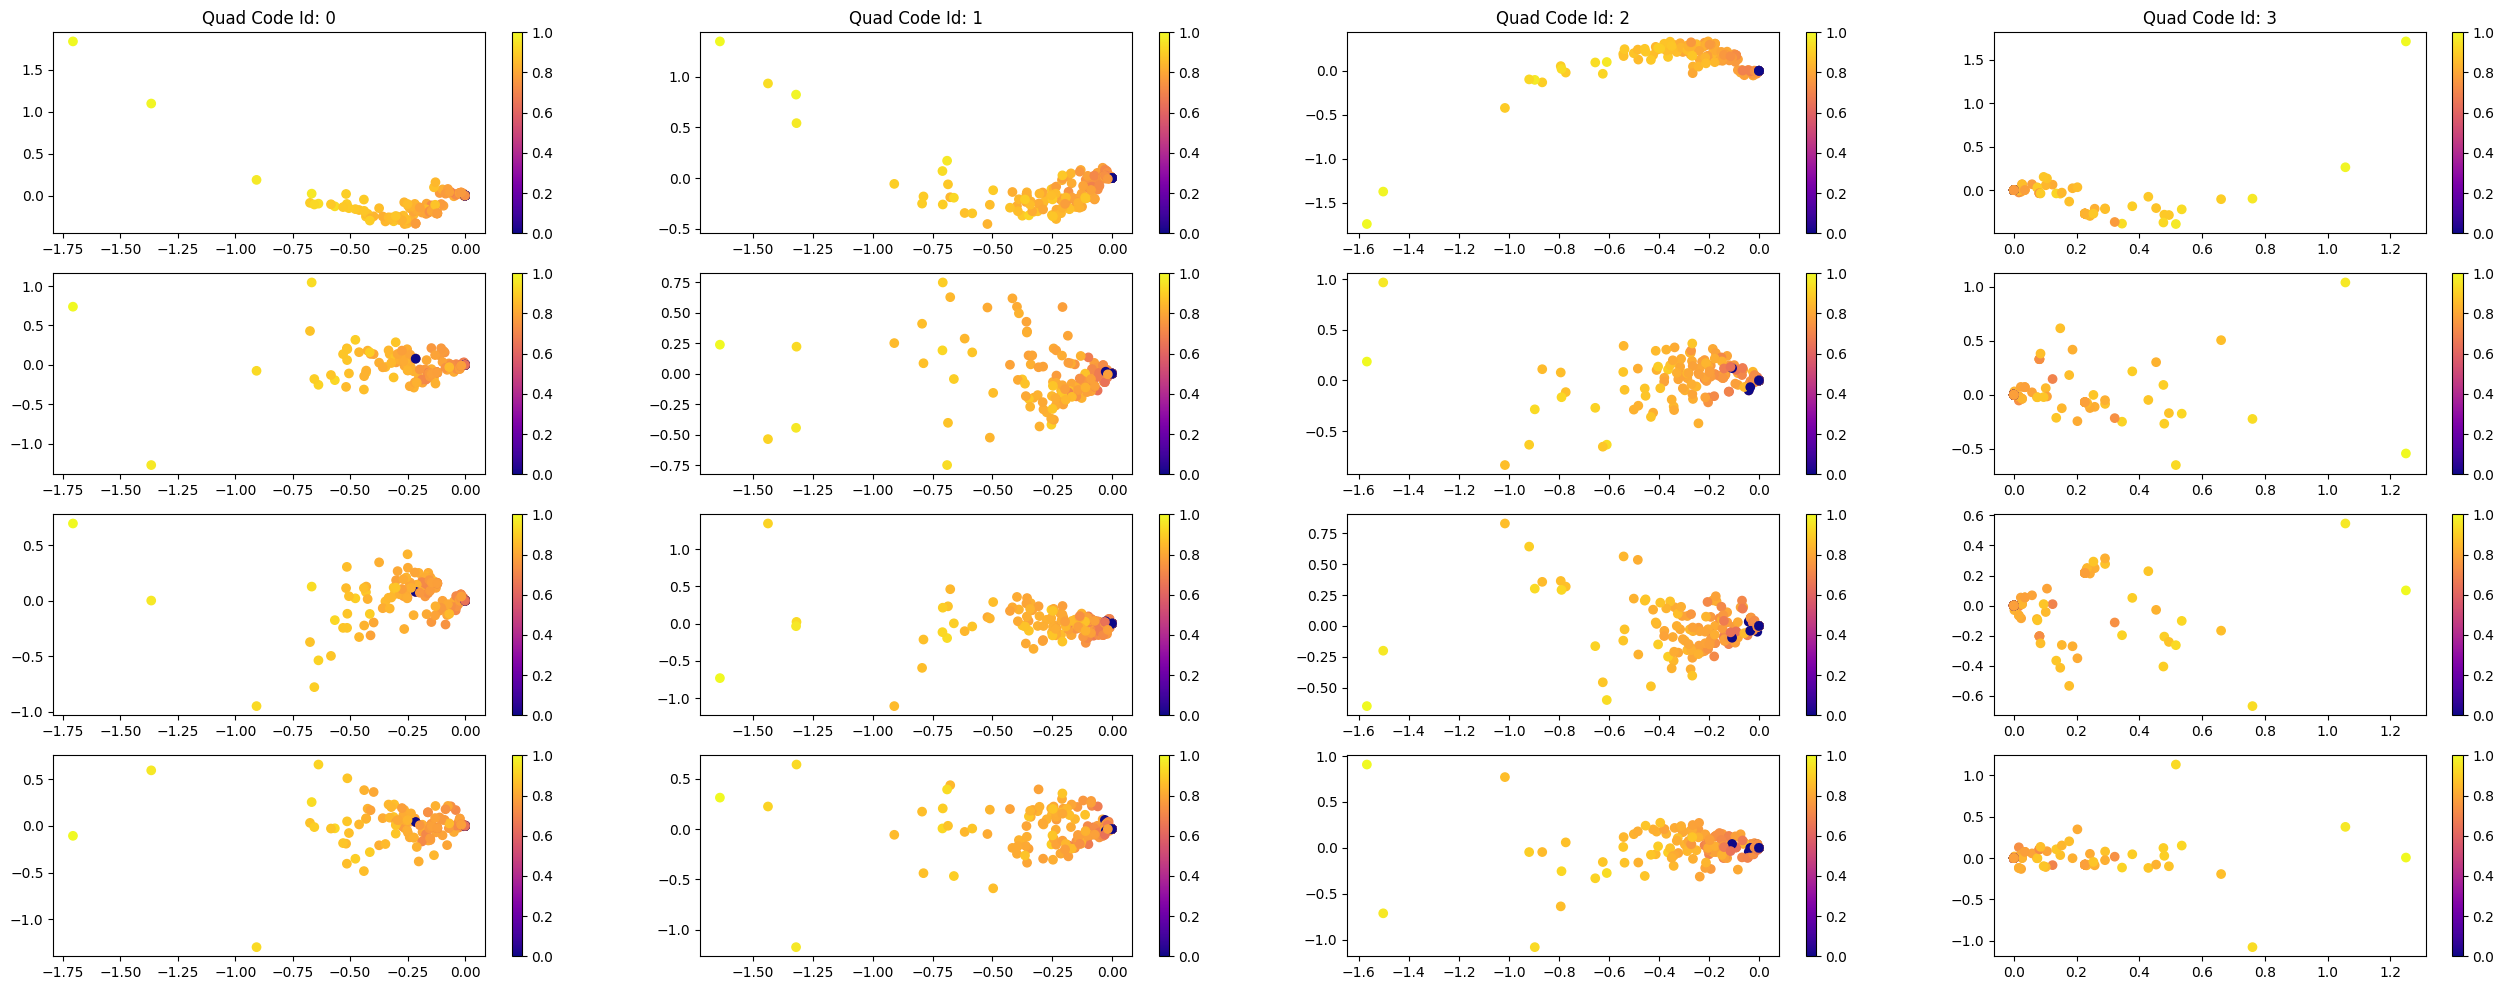

In [19]:
from scipy.linalg import svd
from mpl_toolkits.mplot3d import Axes3D

# Get the unique Quad Code Ids
quad_codes = df_network_raw['Quad Code Id'].unique()

# Create a figure with subplots
num_layers = len(quad_codes)
# fig, axes = plt.subplots(2, num_layers, figsize=(num_layers * 8, 6))
fig, axes = plt.subplots(4, num_layers, figsize=(num_layers * 8, 12))
# fig, axes = plt.subplots(1, num_layers, figsize=(num_layers * 8, 6),
#                          subplot_kw={'projection': '3d'})

# Create the relevant network on a given time frame.
df_network_plot = create_network_ym(year=1, month=4)
# df_network_plot = create_network_y(year=1)

# Full set of nodes
node_list = np.arange(200)

# Number of components
k = 5

# Iterate over each unique Quad Code Id and plot the corresponding layer
for i, code in enumerate(quad_codes):
    # Create graph structure (directed) for the given layer
    # df_layer = df_network_plot[df_network_plot['Quad Code Id'] == code].drop(columns='Quad Code Id')
    # G_layer = nx.DiGraph()
    # G_layer.add_nodes_from(node_list)
    # weighted_tuples = [tuple(row) for row in df_layer.to_numpy()]
    # G_layer.add_weighted_edges_from(weighted_tuples)
    G_layer = nx.DiGraph()
    G_layer.add_nodes_from(node_list)
    G_layer.add_edges_from(zip(df_network_plot[df_network_plot['Quad Code Id'] == code]['Actor Country Id'], 
                                df_network_plot[df_network_plot['Quad Code Id'] == code]['Recipient Country Id']))
    
    # Compute SVD
    A = nx.to_numpy_array(G_layer)
    U, Sigma, Vt = svd(A)
    
    # Left and right eigenvectors
    left_evecs = U[:,:k]; right_evecs = Vt.T[:,:k]
    
    #Compute the embeddings
    Sigma_half = np.sqrt(Sigma)
    X = left_evecs @ np.diag(Sigma_half[:k])
    X_prime = right_evecs @ np.diag(Sigma_half[:k])
    
    # Colour by the number of counts for that node
    weights_out = df_network_plot.groupby('Actor Country Id')['Weight'].sum()
    weights_in = df_network_plot.groupby('Recipient Country Id')['Weight'].sum()
    idcs_out = weights_out.index.to_numpy()
    idcs_in = weights_in.index.to_numpy()
    missing_idcs_in = np.setdiff1d(node_list, idcs_in)
    missing_idcs_out = np.setdiff1d(node_list, idcs_out)
    colours_out = pd.Series(index=node_list)
    colours_in = pd.Series(index=node_list)
    colours_out.update(weights_out)
    colours_in.update(weights_in)
    colours_out[missing_idcs_out] = 0
    colours_in[missing_idcs_in] = 0
    colours_out = colours_out.to_numpy()
    colours_in = colours_in.to_numpy()
    colours_out = np.log10(colours_out / colours_out.max() + 1e-10)
    colours_in = np.log10(colours_in / colours_in.max() + 1e-10)
    
    ## Plots
    cmap = plt.cm.plasma

    # Plot first vs second component
    # axes[0, i].scatter(X[:,0], X[:,1], c=colours_out, cmap=cmap)
    # axes[0, i].set_title(f'Quad Code Id: {code}')
    # norm_out = plt.Normalize(0, 1)
    # cbar_out = plt.colorbar(plt.cm.ScalarMappable(norm=norm_out, cmap=cmap), ax=axes[0, i])
    
    # axes[1, i].scatter(X_prime[:,0], X_prime[:,1], c=colours_in, cmap=cmap)
    # norm_in = plt.Normalize(0, 1)
    # cbar_in = plt.colorbar(plt.cm.ScalarMappable(norm=norm_in, cmap=cmap), ax=axes[1, i])
    
    # if i == 0:
    #     axes[0,i].set_ylabel('Out-connections')
    #     axes[1,i].set_ylabel('In-connections')
    
    # Plot multiple components against first component
    axes[0, i].scatter(X[:,0], X[:,1], c=colours_out, cmap=cmap)
    axes[0, i].set_title(f'Quad Code Id: {code}')
    norm_out = plt.Normalize(0, 1)
    cbar_out = plt.colorbar(plt.cm.ScalarMappable(norm=norm_out, cmap=cmap), ax=axes[0, i])
    axes[1, i].scatter(X[:,0], X[:,2], c=colours_in, cmap=cmap)
    norm_in = plt.Normalize(0, 1)
    cbar_in = plt.colorbar(plt.cm.ScalarMappable(norm=norm_in, cmap=cmap), ax=axes[1, i])
    axes[2, i].scatter(X[:,0], X[:,3], c=colours_in, cmap=cmap)
    norm_in = plt.Normalize(0, 1)
    cbar_in = plt.colorbar(plt.cm.ScalarMappable(norm=norm_in, cmap=cmap), ax=axes[2, i])
    axes[3, i].scatter(X[:,0], X[:,4], c=colours_in, cmap=cmap)
    norm_in = plt.Normalize(0, 1)
    cbar_in = plt.colorbar(plt.cm.ScalarMappable(norm=norm_in, cmap=cmap), ax=axes[3, i])
    
    # Plot a 3d plot of first 3 components
    # axes[i].scatter(X[:,0], X[:,1], X[:,2], c=colours_out, cmap=cmap)
    # axes[i].set_title(f'Quad Code Id: {code}')
    # norm_out = plt.Normalize(0, 1)
    # cbar_out = plt.colorbar(plt.cm.ScalarMappable(norm=norm_out, cmap=cmap), ax=axes[i])

### Fit an SBM to each layer and compare clustering

In [96]:
"""
Use spectral clustering to each layer.
"""
from sklearn.cluster import SpectralClustering
from sparsebm import SBM
from sparsebm.utils import ARI
from sparsebm import ModelSelection

# Get the unique Quad Code Ids
quad_codes = df_network_raw['Quad Code Id'].unique()

# Create a figure with subplots
num_layers = len(quad_codes)

# Create the relevant network on a given time frame.
df_network_plot = create_network_ym(year=1, month=1)

# Step 1: Get the unique node list across all layers
all_nodes = set()
for code in quad_codes:
    df_layer = (
        df_network_plot[df_network_plot['Quad Code Id'] == code]
        [['Actor Country Id', 'Recipient Country Id']]
    )
    all_nodes.update(df_layer['Actor Country Id'])
    all_nodes.update(df_layer['Recipient Country Id'])

# Convert to sorted list (for consistent ordering)
# node_list = sorted(all_nodes)
node_list = np.arange(200)

# Number of clusters to fit
n_clusters = 4 

# Groups dictionary
groups_dict = {}

# Iterate over each unique Quad Code Id and plot the corresponding layer
for i, code in enumerate(quad_codes):
# for i, code in enumerate([0]):
    # Create graph structure (directed) for the given layer
    # Create a directed graph with all nodes in node_list
    G_layer = nx.DiGraph()
    G_layer.add_nodes_from(node_list)
    G_layer.add_edges_from(zip(df_network_plot[df_network_plot['Quad Code Id'] == code]['Actor Country Id'], 
                                df_network_plot[df_network_plot['Quad Code Id'] == code]['Recipient Country Id']))
    adj_matrix = nx.to_numpy_array(G_layer, nodelist=node_list)
    print(adj_matrix.shape)

    # Initialise and fit SBM
    # model_selection = ModelSelection("SBM")
    # models = model_selection.fit(adj_matrix, symmetric=False)
    # labels = models.best.labels
    sbm_model = SBM(n_clusters=n_clusters)
    sbm_model.fit(adj_matrix, symmetric=False)
    labels = sbm_model.labels
    
    # # Spectral clustering to the adjacency for the layer
    # sc = SpectralClustering(n_clusters=n_clusters, affinity='precomputed', 
    #                         assign_labels='discretize', random_state=0)
    # labels = sc.fit_predict(sym_adj_matrix)
    
    layer_dict = {node: labels[j] for j, node in enumerate(node_list)}
    groups_dict[i] = layer_dict
    
group_array = np.full((len(node_list), num_layers), fill_value=-1)
for layer_index, (layer_name, layer_dict) in enumerate(groups_dict.items()):
    for node in node_list:
        group_array[node, layer_index] = layer_dict[node]

---------- START RANDOM INITIALIZATIONS ---------- 


(200, 200)


0 of 100 Initializations:  [  0% ] |               | [ Elapsed Time: 0:00:00 ]
3 of 100 Initializations:  [  3% ] |               | [ Elapsed Time: 0:00:00 ]
7 of 100 Initializations:  [  7% ] |#              | [ Elapsed Time: 0:00:00 ]
11 of 100 Initializations:  [ 11% ] |#             | [ Elapsed Time: 0:00:00 ]
16 of 100 Initializations:  [ 16% ] |##            | [ Elapsed Time: 0:00:00 ]
21 of 100 Initializations:  [ 21% ] |##            | [ Elapsed Time: 0:00:00 ]
25 of 100 Initializations:  [ 25% ] |###           | [ Elapsed Time: 0:00:00 ]
28 of 100 Initializations:  [ 28% ] |###           | [ Elapsed Time: 0:00:00 ]
31 of 100 Initializations:  [ 31% ] |####          | [ Elapsed Time: 0:00:00 ]
35 of 100 Initializations:  [ 35% ] |####          | [ Elapsed Time: 0:00:00 ]
37 of 100 Initializations:  [ 37% ] |#####         | [ Elapsed Time: 0:00:00 ]
40 of 100 Initializations:  [ 40% ] |#####         | [ Elapsed Time: 0:00:00 ]
44 of 100 Initializations:  [ 44% ] |######        |

(200, 200)


0 of 100 Initializations:  [  0% ] |               | [ Elapsed Time: 0:00:00 ]
3 of 100 Initializations:  [  3% ] |               | [ Elapsed Time: 0:00:00 ]
6 of 100 Initializations:  [  6% ] |               | [ Elapsed Time: 0:00:00 ]
8 of 100 Initializations:  [  8% ] |#              | [ Elapsed Time: 0:00:00 ]
11 of 100 Initializations:  [ 11% ] |#             | [ Elapsed Time: 0:00:00 ]
13 of 100 Initializations:  [ 13% ] |#             | [ Elapsed Time: 0:00:00 ]
16 of 100 Initializations:  [ 16% ] |##            | [ Elapsed Time: 0:00:00 ]
19 of 100 Initializations:  [ 19% ] |##            | [ Elapsed Time: 0:00:00 ]
22 of 100 Initializations:  [ 22% ] |###           | [ Elapsed Time: 0:00:00 ]
25 of 100 Initializations:  [ 25% ] |###           | [ Elapsed Time: 0:00:00 ]
28 of 100 Initializations:  [ 28% ] |###           | [ Elapsed Time: 0:00:00 ]
31 of 100 Initializations:  [ 31% ] |####          | [ Elapsed Time: 0:00:00 ]
35 of 100 Initializations:  [ 35% ] |####          |

(200, 200)


0 of 100 Initializations:  [  0% ] |               | [ Elapsed Time: 0:00:00 ]
3 of 100 Initializations:  [  3% ] |               | [ Elapsed Time: 0:00:00 ]
6 of 100 Initializations:  [  6% ] |               | [ Elapsed Time: 0:00:00 ]
8 of 100 Initializations:  [  8% ] |#              | [ Elapsed Time: 0:00:00 ]
11 of 100 Initializations:  [ 11% ] |#             | [ Elapsed Time: 0:00:00 ]
14 of 100 Initializations:  [ 14% ] |#             | [ Elapsed Time: 0:00:00 ]
17 of 100 Initializations:  [ 17% ] |##            | [ Elapsed Time: 0:00:00 ]
21 of 100 Initializations:  [ 21% ] |##            | [ Elapsed Time: 0:00:00 ]
25 of 100 Initializations:  [ 25% ] |###           | [ Elapsed Time: 0:00:00 ]
28 of 100 Initializations:  [ 28% ] |###           | [ Elapsed Time: 0:00:00 ]
31 of 100 Initializations:  [ 31% ] |####          | [ Elapsed Time: 0:00:00 ]
35 of 100 Initializations:  [ 35% ] |####          | [ Elapsed Time: 0:00:00 ]
38 of 100 Initializations:  [ 38% ] |#####         |

(200, 200)


0 of 100 Initializations:  [  0% ] |               | [ Elapsed Time: 0:00:00 ]
3 of 100 Initializations:  [  3% ] |               | [ Elapsed Time: 0:00:00 ]
6 of 100 Initializations:  [  6% ] |               | [ Elapsed Time: 0:00:00 ]
9 of 100 Initializations:  [  9% ] |#              | [ Elapsed Time: 0:00:00 ]
12 of 100 Initializations:  [ 12% ] |#             | [ Elapsed Time: 0:00:00 ]
16 of 100 Initializations:  [ 16% ] |##            | [ Elapsed Time: 0:00:00 ]
21 of 100 Initializations:  [ 21% ] |##            | [ Elapsed Time: 0:00:00 ]
25 of 100 Initializations:  [ 25% ] |###           | [ Elapsed Time: 0:00:00 ]
30 of 100 Initializations:  [ 30% ] |####          | [ Elapsed Time: 0:00:00 ]
35 of 100 Initializations:  [ 35% ] |####          | [ Elapsed Time: 0:00:00 ]
40 of 100 Initializations:  [ 40% ] |#####         | [ Elapsed Time: 0:00:00 ]
44 of 100 Initializations:  [ 44% ] |######        | [ Elapsed Time: 0:00:00 ]
49 of 100 Initializations:  [ 49% ] |######        |

In [110]:
# Examine the ARI between layers
ari12 = ARI(group_array[:,0], group_array[:,1])
ari13 = ARI(group_array[:,0], group_array[:,2]) 
ari14 = ARI(group_array[:,0], group_array[:,3])
ari23 = ARI(group_array[:,1], group_array[:,2])
ari24 = ARI(group_array[:,1], group_array[:,3])
ari34 = ARI(group_array[:,2], group_array[:,3])

print(f"ARI layer 1 to layer 2: {round(ari12, 2)}")
print(f"ARI layer 1 to layer 3: {round(ari13, 2)}")
print(f"ARI layer 1 to layer 4: {round(ari14, 2)}")
print(f"ARI layer 2 to layer 3: {round(ari23, 2)}")
print(f"ARI layer 2 to layer 4: {round(ari24, 2)}")
print(f"ARI layer 3 to layer 4: {round(ari34, 2)}")

ARI layer 1 to layer 2: 0.34
ARI layer 1 to layer 3: 0.6
ARI layer 1 to layer 4: 0.28
ARI layer 2 to layer 3: 0.37
ARI layer 2 to layer 4: 0.24
ARI layer 3 to layer 4: 0.28


### Degree plots for each layer

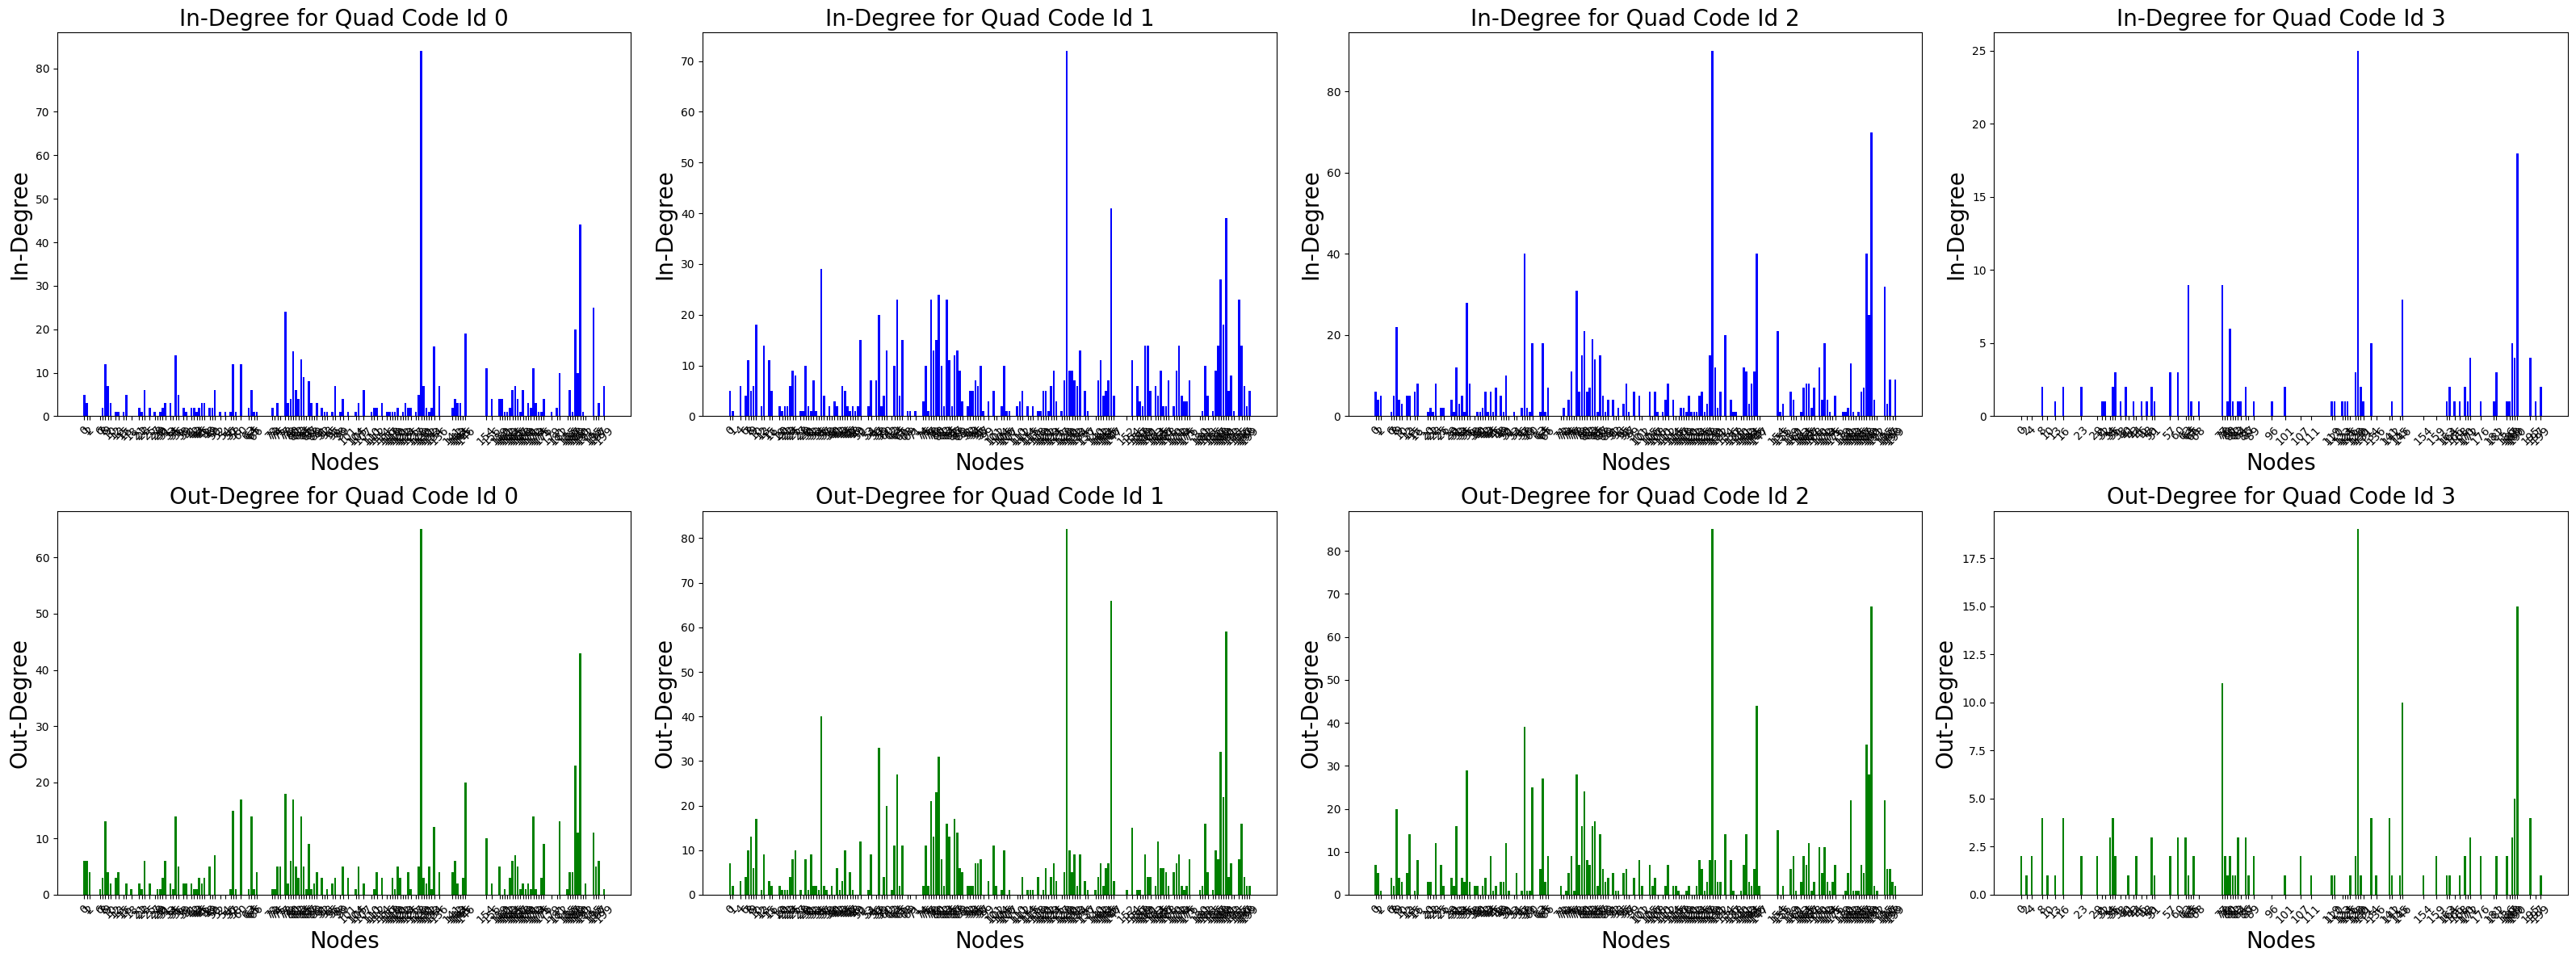

In [233]:
fig, axes = plt.subplots(2, num_layers, figsize=(num_layers * 8, 12))

# Create the relevant network on a given time frame.
df_network_plot = create_network_ym(year=0, month=1)

num_actrs = df_network_raw['Actor Country Id'].nunique()
df_degrees = np.zeros((num_actrs, num_layers, 2), dtype=int)

# Iterate over each unique Quad Code Id and plot the corresponding layer
for i, code in enumerate(quad_codes):
    G_layer = nx.DiGraph()
    G_layer.add_edges_from(zip(df_network_plot[df_network_plot['Quad Code Id'] == code]['Actor Country Id'], 
                                df_network_plot[df_network_plot['Quad Code Id'] == code]['Recipient Country Id']))
    
    # Calculate the degrees of each node
    in_degrees = dict(G_layer.in_degree())
    out_degrees = dict(G_layer.out_degree())
 
    # Plot in-degrees (first row)
    axes[0, i].bar(in_degrees.keys(), in_degrees.values(), color='b')
    axes[0, i].set_title(f'In-Degree for Quad Code Id {code}', fontsize=20)
    axes[0, i].set_xlabel('Nodes', fontsize=20)
    axes[0, i].set_ylabel('In-Degree', fontsize=20)
    axes[0, i].set_xticks(list(in_degrees.keys()))  # Set x-ticks to the node IDs
    axes[0, i].set_xticklabels(list(in_degrees.keys()), rotation=45)  # Rotate for better readability
    
    # Plot out-degrees (second row)
    axes[1, i].bar(out_degrees.keys(), out_degrees.values(), color='g')
    axes[1, i].set_title(f'Out-Degree for Quad Code Id {code}', fontsize=20)
    axes[1, i].set_xlabel('Nodes', fontsize=20)
    axes[1, i].set_ylabel('Out-Degree', fontsize=20)
    axes[1, i].set_xticks(list(out_degrees.keys()))  # Set x-ticks to the node IDs
    axes[1, i].set_xticklabels(list(out_degrees.keys()), rotation=45)  # Rotate for better readability

plt.tight_layout();
plt.show()

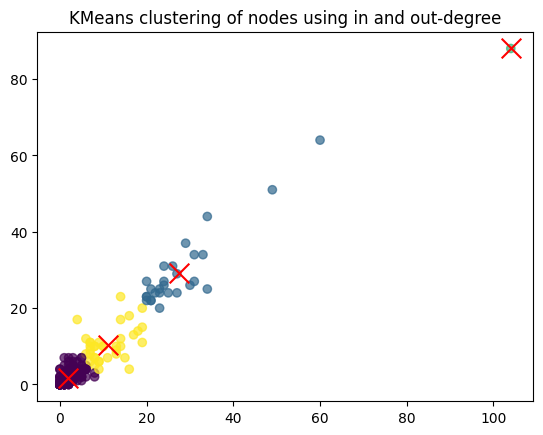

In [114]:
from sklearn.cluster import KMeans

# Create the relevant network on a given time frame.
df_network_plot = create_network_y(year=0)

num_actrs = df_network_raw['Actor Country Id'].nunique()
df_degrees = np.zeros((num_actrs, num_layers, 2), dtype=int)
df_layer_groups = np.zeros((num_actrs, num_layers))

# Iterate over each unique Quad Code Id and plot the corresponding layer
for i, code in enumerate(quad_codes):
    G_layer = nx.DiGraph()
    G_layer.add_edges_from(zip(df_network_plot[df_network_plot['Quad Code Id'] == code]['Actor Country Id'], 
                                df_network_plot[df_network_plot['Quad Code Id'] == code]['Recipient Country Id']))
    
    # Calculate the degrees of each node
    in_degrees = dict(G_layer.in_degree())
    out_degrees = dict(G_layer.out_degree())
 
    for node, degree in in_degrees.items():
        df_degrees[node, i, 0] = degree
    for node, degree in out_degrees.items():
        df_degrees[node, i, 1] = degree
        
for layer in range(4):
    kmeans = KMeans(n_clusters=4)
    kmeans.fit(df_degrees[:, layer, :])

    labels = kmeans.labels_
    centroids = kmeans.cluster_centers_
    
    df_layer_groups[:, layer] = labels

plt.scatter(df_degrees[:, layer, 0], df_degrees[:, layer, 1], 
            c=labels, cmap='viridis', marker='o', alpha=0.7)
plt.scatter(centroids[:, 0], centroids[:, 1], c='red', marker='x', s=200, label='Centroids')
plt.title("KMeans clustering of nodes using in and out-degree");

In [115]:
from sklearn.metrics import adjusted_rand_score

ari_12 = adjusted_rand_score(df_layer_groups[:,0], df_layer_groups[:,1]) 
ari_13 = adjusted_rand_score(df_layer_groups[:,0], df_layer_groups[:,2])  
ari_14 = adjusted_rand_score(df_layer_groups[:,0], df_layer_groups[:,3])  
ari_23 = adjusted_rand_score(df_layer_groups[:,1], df_layer_groups[:,2])  
ari_24 = adjusted_rand_score(df_layer_groups[:,1], df_layer_groups[:,3])  
ari_34 = adjusted_rand_score(df_layer_groups[:,2], df_layer_groups[:,3])  

print(f"ARI layer 1 to layer 2: {round(ari_12, 2)}")
print(f"ARI layer 1 to layer 3: {round(ari_13, 2)}")
print(f"ARI layer 1 to layer 4: {round(ari_14, 2)}")
print(f"ARI layer 2 to layer 3: {round(ari_23, 2)}")
print(f"ARI layer 2 to layer 4: {round(ari_24, 2)}")
print(f"ARI layer 3 to layer 4: {round(ari_34, 2)}")


ARI layer 1 to layer 2: 0.44
ARI layer 1 to layer 3: 0.66
ARI layer 1 to layer 4: 0.42
ARI layer 2 to layer 3: 0.57
ARI layer 2 to layer 4: 0.53
ARI layer 3 to layer 4: 0.51


# Considering as a network point process

### Counts for point processes in each layer

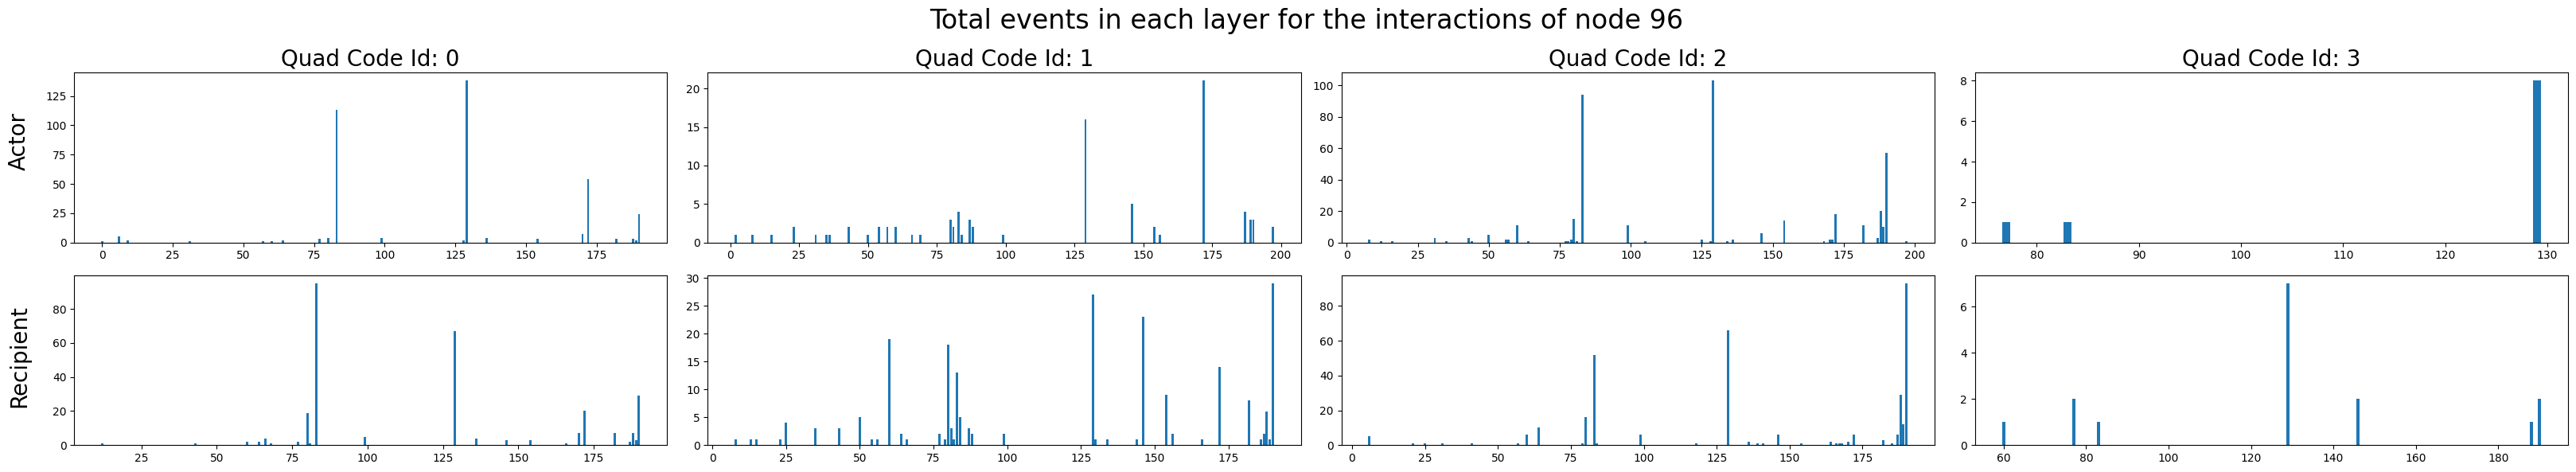

In [7]:
act_ctry_id = 96

# Get the unique Quad Code Ids
quad_codes = df_network_raw['Quad Code Id'].unique()

# Create a figure with subplots
num_layers = len(quad_codes)
fig, axes = plt.subplots(2, num_layers, figsize=(num_layers * 8, 6))

# Create the relevant network pp on a given time frame.
df_network_pp = create_network_pp(year=1, y=True)

# Iterate over each unique Quad Code Id and plot the corresponding layer
for type in [0, 1]:
    if type == 0:
        data = df_network_pp[df_network_pp['Actor Country Id'] == act_ctry_id]
    if type == 1:
        data = df_network_pp[df_network_pp['Recipient Country Id'] == act_ctry_id]  
              
    for i, code in enumerate(quad_codes):
        data_quad = data[data['Quad Code Id'] == code]
        if type == 0:
            axes[type, i].bar(x=data_quad['Recipient Country Id'], 
                              height=data_quad['Count pp'])
            axes[type, i].set_title(f'Quad Code Id: {code}',
                            fontsize=20)
        if type == 1:
            axes[type, i].bar(x=data_quad['Actor Country Id'], 
                              height=data_quad['Count pp'])

fig.suptitle(f"Total events in each layer for the interactions of node {act_ctry_id}",
             fontsize=24);
# Set row titles (on the left of each row)
fig.text(-0.01, 0.7, 'Actor', va='center', rotation='vertical', fontsize=20);
fig.text(-0.01, 0.25, 'Recipient', va='center', rotation='vertical', fontsize=20);
plt.tight_layout();  
plt.show();

### Intensity function for each layer

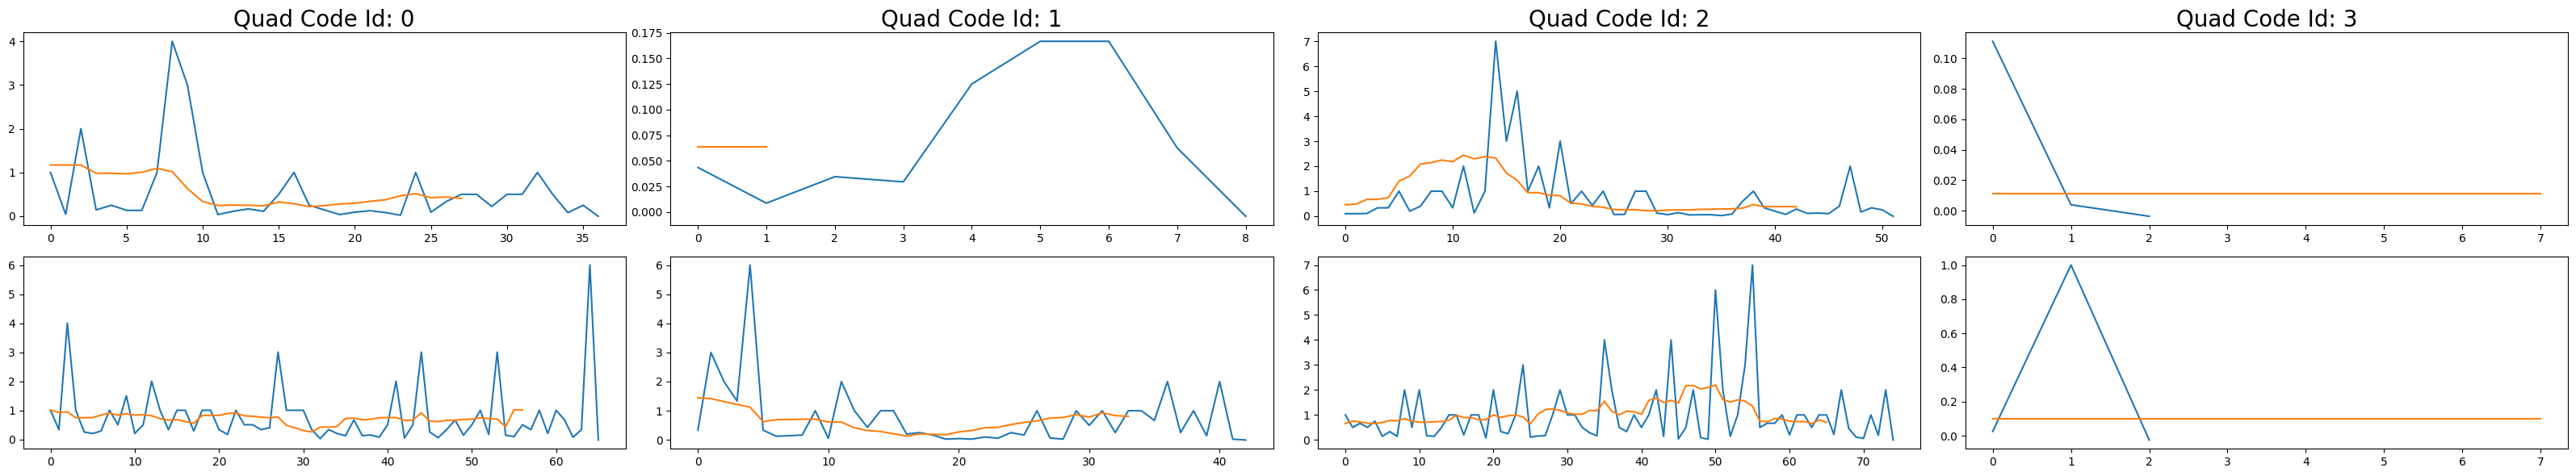

In [230]:
# Create the relevant network pp on a given time frame.
df_network_pp = create_network_pp(year=1, y=True)

fig, axes = plt.subplots(2, num_layers, figsize=(num_layers * 8, 6))

node1 = 172; node2 = 190

for i, code in enumerate(quad_codes):
    df_network_plot = df_network_pp[(df_network_pp['Actor Country Id'] == node1)
                                  &
                                  (df_network_pp['Recipient Country Id'] == node2)
                                  &
                                  (df_network_pp['Quad Code Id'] == code)]
    
    day_pp = df_network_plot['Day pp'].reset_index(drop=True)
    if len(day_pp) != 0:
        day_pp = day_pp[0]
        day_pp.sort()
    else:
        continue
       
    times, counts = np.unique(day_pp, return_counts=True)
    time_intervals = np.diff(times, append=times[0])
    intensity = counts / time_intervals

    window_size = 10
    smoothed_intensity = np.convolve(intensity, np.ones(window_size)/window_size, mode='valid')

    axes[0,i].plot(intensity);
    axes[0,i].plot(smoothed_intensity);
    axes[0, i].set_title(f'Quad Code Id: {code}', fontsize=20)
    
    df_network_plot = df_network_pp[(df_network_pp['Actor Country Id'] == node2)
                                  &
                                  (df_network_pp['Recipient Country Id'] == node1)
                                  &
                                  (df_network_pp['Quad Code Id'] == code)]
    
    day_pp = df_network_plot['Day pp'].reset_index(drop=True)[0]
    day_pp.sort()
       
    times, counts = np.unique(day_pp, return_counts=True)
    time_intervals = np.diff(times, append=times[0])
    intensity = counts / time_intervals

    window_size = 10
    smoothed_intensity = np.convolve(intensity, np.ones(window_size)/window_size, mode='valid')

    axes[1,i].plot(intensity);
    axes[1,i].plot(smoothed_intensity);
       
plt.tight_layout();  
plt.show()

# Fit the model to the data

### Process the data

In [41]:
## Construct the adjacency tensor
df_network_plot = create_network_y(year=1)

node_list = df_meta['Country Id'].unique()
num_nodes = len(node_list)
num_layers = 4

adj_tensor = np.zeros((num_layers, num_nodes, num_nodes))

for code in range(4):
    G_layer = nx.DiGraph()
    G_layer.add_nodes_from(node_list)
    G_layer.add_edges_from((actor, recipient) for actor, recipient in zip(
                            df_network_plot[df_network_plot['Quad Code Id'] == code]['Actor Country Id'], 
                            df_network_plot[df_network_plot['Quad Code Id'] == code]['Recipient Country Id'])
                        if actor in node_list and recipient in node_list)

    adj_tensor[code,:,:] = nx.to_numpy_array(G_layer)

## Construct feature vectors
df_features = df_meta.drop(columns='Country Id')
features = df_meta.drop(columns='Country Id').to_numpy()

In [43]:
df_features.to_csv('simulations/POLECAT/df_features.csv')

### Run the model

In [37]:
from src.variational_bayes import VariationalBayes

num_global_groups = 6
max_num_layer_groups = 6
features_length = features.shape[1]

VB = VariationalBayes(num_nodes=num_nodes, num_layers=num_layers,
                      adj_tensor=adj_tensor, features=features,
                      M_w=6, M_u=6, M_zeta=6)
VB.run_VB_scheme(n_CAVI_its=5, 
                 num_mc=10000, 
                 num_grad_steps=5)

Iteration 1 of 5
Updating u
Updating w


KeyboardInterrupt: 

In [36]:
amax_w = VB.phi_w.round().argmax(axis=1)
amax_u_0 = VB.phi_u.round()[0,:,:].argmax(axis=1)
amax_u_1 = VB.phi_u.round()[1,:,:].argmax(axis=1)
amax_u_2 = VB.phi_u.round()[2,:,:].argmax(axis=1)
amax_u_3 = VB.phi_u.round()[3,:,:].argmax(axis=1)

# print("Layer-level groups:")
# print(VB.phi_zeta.round()[amax_w, amax_u_0, :].argmax(axis=1))
# print(VB.phi_zeta.round()[amax_w, amax_u_1, :].argmax(axis=1))
# print(VB.phi_zeta.round()[amax_w, amax_u_2, :].argmax(axis=1))
# print(VB.phi_zeta.round()[amax_w, amax_u_3, :].argmax(axis=1))
# print("Global groups:")
# print(amax_w)

map_country = pd.read_csv('data/POLECAT/processed_data/map_country.csv',
                          header=None)
map_id_to_string = map_country.set_index(1)[0].to_dict()

df_groups = pd.DataFrame({'Country Id': node_list})
df_groups['Global Group'] = amax_w
df_groups['Country'] = df_groups['Country Id'].map(map_id_to_string)
df_groups = df_groups[['Country', 'Global Group']]
df_groups[df_groups['Country'].isin(['United Kingdom', 'United States',
                                     'France', 'Russia', 'China', 'Germany',
                                     'Zambia', 'Namibia', 'Nigeria'])]

,Country,Global Group
30,China,2
50,France,2
53,Germany,2
104,Namibia,1
111,Nigeria,2
125,Russia,2
162,United Kingdom,2
163,United States,2
170,Zambia,1
